<a href="https://colab.research.google.com/github/charanraikar/Efficient-transfer-learning-s1-s4/blob/main/efficient_transfer_learning(s1_s4).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CELL 1: Install dependencies and imports
# ============================================================
!pip install torchinfo matplotlib seaborn scikit-learn kaggle --quiet

import os, time, copy, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torchinfo import summary
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB


In [ ]:
# ============================================================
# CELL 2 (FIXED): Force overwrite during unzip
# ============================================================
import os, json

os.environ["KAGGLE_TOKEN"] = "YOUR_NEW_TOKEN_HERE"

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
with open(os.path.expanduser("~/.kaggle/kaggle.json"), "w") as f:
    json.dump({"username": "YOUR_KAGGLE_USERNAME", "key": os.environ["KAGGLE_TOKEN"]}, f)

!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d puneet6060/intel-image-classification --quiet

# The -o flag forces overwrite of ALL files without prompting
!unzip -o -q intel-image-classification.zip -d intel_data

# Verify download
print("✓ Download complete! Verifying structure...\n")
for split in ['seg_train/seg_train', 'seg_test/seg_test']:
    path = f"intel_data/{split}"
    if os.path.exists(path):
        classes = [c for c in os.listdir(path) if not c.startswith('.')]
        total = sum(len(os.listdir(f"{path}/{c}")) for c in classes)
        print(f"✓ {split}: {total} images | classes: {classes}")
    else:
        print(f"✗ Missing: {path}")

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
✓ Download complete! Verifying structure...

✓ seg_train/seg_train: 14034 images | classes: ['buildings', 'sea', 'mountain', 'forest', 'glacier', 'street']
✓ seg_test/seg_test: 3000 images | classes: ['buildings', 'sea', 'mountain', 'forest', 'glacier', 'street']


In [ ]:
# ============================================================
# CELL 3: Central config — change ONE place to tweak everything
# ============================================================
CONFIG = {
    # Paths
    "train_dir": "intel_data/seg_train/seg_train",
    "test_dir":  "intel_data/seg_test/seg_test",

    # Model
    "backbone":    "resnet18",   # "resnet18" or "mobilenet_v2"
    "num_classes": 6,
    "img_size":    224,

    # Training
    "batch_size":  32,
    "num_epochs":  20,
    "lr":          1e-3,
    "weight_decay": 1e-4,
    "patience":    4,            # early stopping patience
    "val_split":   0.15,         # fraction of train set used for validation

    # Experiment
    "strategies":  ["S1", "S2", "S3", "S4"],
    "seed":        42,
}

CLASS_NAMES = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

# Reproducibility
torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
print("Config loaded. Backbone:", CONFIG["backbone"])

Config loaded. Backbone: resnet18


In [ ]:
# ============================================================
# CELL 4: DataLoaders with augmentation (train) and normalization (val/test)
# ============================================================
# ImageNet normalization stats (required for pretrained models!)
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_test_transform = transforms.Compose([
    transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# Load full training set then split off validation
full_train = datasets.ImageFolder(CONFIG["train_dir"], transform=train_transform)
test_set   = datasets.ImageFolder(CONFIG["test_dir"],  transform=val_test_transform)

val_size   = int(len(full_train) * CONFIG["val_split"])
train_size = len(full_train) - val_size
train_set, val_set = random_split(
    full_train, [train_size, val_size],
    generator=torch.Generator().manual_seed(CONFIG["seed"])
)

# Apply val transform to val_set (override the train augmentation)
val_set.dataset = copy.deepcopy(full_train)
val_set.dataset.transform = val_test_transform

train_loader = DataLoader(train_set, batch_size=CONFIG["batch_size"], shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_set,   batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=CONFIG["batch_size"], shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")
print(f"Batches — Train: {len(train_loader)} | Val: {len(val_loader)} | Test: {len(test_loader)}")

Train: 11929 | Val: 2105 | Test: 3000
Batches — Train: 373 | Val: 66 | Test: 94


In [ ]:
# ============================================================
# CELL 5: Model factory with freezing strategies S1–S4
# ============================================================

def build_model(backbone_name, num_classes, strategy):
    """
    Returns a pretrained model with layers frozen according to strategy:
      S1 = freeze ALL backbone layers (head only trains)
      S2 = unfreeze last residual/inverted-residual block
      S3 = unfreeze last 2 blocks
      S4 = unfreeze everything (full fine-tune)
    """
    if backbone_name == "resnet18":
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        # Replace final FC layer
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)

        # Named layer groups (in order of depth)
        layer_groups = [model.layer1, model.layer2, model.layer3, model.layer4]

    elif backbone_name == "mobilenet_v2":
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)

        # MobileNetV2 has 19 inverted residual blocks (features[0]..features[18])
        # We treat the last 4 as "last block" and last 8 as "last 2 blocks"
        n = len(model.features)
        layer_groups = [
            model.features[:n//4],
            model.features[n//4:n//2],
            model.features[n//2:3*n//4],
            model.features[3*n//4:],
        ]

    # Step 1: freeze EVERYTHING
    for param in model.parameters():
        param.requires_grad = False

    # Step 2: selectively unfreeze based on strategy
    if backbone_name == "resnet18":
        classifier = model.fc
    else:
        classifier = model.classifier

    # Always unfreeze the classifier head
    for param in classifier.parameters():
        param.requires_grad = True

    if strategy == "S1":
        pass  # head only — already done above

    elif strategy == "S2":
        for param in layer_groups[-1].parameters():
            param.requires_grad = True

    elif strategy == "S3":
        for param in layer_groups[-1].parameters():
            param.requires_grad = True
        for param in layer_groups[-2].parameters():
            param.requires_grad = True

    elif strategy == "S4":
        for param in model.parameters():
            param.requires_grad = True  # unfreeze everything

    # Count trainable params
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  [{strategy}] Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

    return model.to(device)

# Quick test — preview trainable param counts for each strategy
print(f"Backbone: {CONFIG['backbone']}")
for s in CONFIG["strategies"]:
    build_model(CONFIG["backbone"], CONFIG["num_classes"], s)

Backbone: resnet18
  [S1] Trainable: 3,078 / 11,179,590 (0.0%)
  [S2] Trainable: 8,396,806 / 11,179,590 (75.1%)
  [S3] Trainable: 10,496,518 / 11,179,590 (93.9%)
  [S4] Trainable: 11,179,590 / 11,179,590 (100.0%)


In [ ]:
# ============================================================
# CELL 6: Training + validation loop with time/memory tracking
# ============================================================

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total   += imgs.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * imgs.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total   += imgs.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    f1 = f1_score(all_labels, all_preds, average='macro')
    return total_loss / total, correct / total, f1, all_preds, all_labels


def run_strategy(strategy):
    """Full train + eval pipeline for one strategy. Returns a result dict."""
    print(f"\n{'='*55}")
    print(f" Running strategy: {strategy}")
    print(f"{'='*55}")

    model     = build_model(CONFIG["backbone"], CONFIG["num_classes"], strategy)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"]
    )
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    best_val_acc  = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    patience_count = 0
    epoch_times   = []
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    # Reset GPU memory stats before training
    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats()

    total_train_start = time.time()

    for epoch in range(CONFIG["num_epochs"]):
        t0 = time.time()

        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step()

        epoch_time = time.time() - t0
        epoch_times.append(epoch_time)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"  Epoch {epoch+1:02d}/{CONFIG['num_epochs']} | "
              f"Train acc: {train_acc:.3f} | Val acc: {val_acc:.3f} | "
              f"Val F1: {val_f1:.3f} | Time: {epoch_time:.1f}s")

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            patience_count = 0
        else:
            patience_count += 1

        # Early stopping
        if patience_count >= CONFIG["patience"]:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    total_train_time = time.time() - total_train_start

    # Peak GPU memory
    if device.type == "cuda":
        peak_mem_mib = torch.cuda.max_memory_allocated() / (1024**2)
    else:
        peak_mem_mib = 0.0

    # Evaluate best model on test set
    model.load_state_dict(best_model_wts)
    _, test_acc, test_f1, test_preds, test_labels = evaluate(model, test_loader, criterion)

    # Model size on disk
    temp_path = f"/tmp/model_{strategy}.pt"
    torch.save(model.state_dict(), temp_path)
    model_size_mb = os.path.getsize(temp_path) / (1024**2)

    result = {
        "strategy":         strategy,
        "test_acc":         round(test_acc, 4),
        "test_f1":          round(test_f1, 4),
        "avg_epoch_time_s": round(np.mean(epoch_times), 2),
        "total_train_time_s": round(total_train_time, 2),
        "peak_mem_mib":     round(peak_mem_mib, 1),
        "model_size_mb":    round(model_size_mb, 2),
        "epochs_trained":   len(epoch_times),
        "history":          history,
        "test_preds":       test_preds,
        "test_labels":      test_labels,
    }

    print(f"\n  ✓ Test Acc: {test_acc:.4f} | F1: {test_f1:.4f}")
    print(f"  ✓ Avg epoch time: {np.mean(epoch_times):.1f}s | "
          f"Peak mem: {peak_mem_mib:.0f} MiB | Model: {model_size_mb:.1f} MB")

    return result

In [ ]:
# ============================================================
# CELL 7 (FINAL): Run all 4 strategies properly
# ============================================================
import time, copy, os
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score

all_results = []

for strategy in CONFIG["strategies"]:
    print(f"\n{'='*55}")
    print(f" Running strategy: {strategy}")
    print(f"{'='*55}")

    model     = build_model(CONFIG["backbone"], CONFIG["num_classes"], strategy)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"]
    )
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    best_val_acc   = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())
    patience_count = 0
    epoch_times    = []
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats()

    total_start = time.time()

    for epoch in range(CONFIG["num_epochs"]):
        t0 = time.time()

        # --- Train ---
        model.train()
        tloss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            tloss   += loss.item() * imgs.size(0)
            _, pred  = out.max(1)
            correct += pred.eq(labels).sum().item()
            total   += imgs.size(0)
        train_acc  = correct / total
        train_loss = tloss   / total

        # --- Validate ---
        model.eval()
        vloss, vcorrect, vtotal = 0.0, 0, 0
        vp, vl = [], []
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                out  = model(imgs)
                loss = criterion(out, labels)
                vloss    += loss.item() * imgs.size(0)
                _, pred   = out.max(1)
                vcorrect += pred.eq(labels).sum().item()
                vtotal   += imgs.size(0)
                vp.extend(pred.cpu().numpy())
                vl.extend(labels.cpu().numpy())
        val_acc  = vcorrect / vtotal
        val_loss = vloss    / vtotal
        val_f1   = f1_score(vl, vp, average='macro')

        scheduler.step()
        epoch_time = time.time() - t0
        epoch_times.append(epoch_time)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"  Epoch {epoch+1:02d}/{CONFIG['num_epochs']} | "
              f"Train: {train_acc:.3f} | Val: {val_acc:.3f} | "
              f"F1: {val_f1:.3f} | Time: {epoch_time:.1f}s")

        if val_acc > best_val_acc:
            best_val_acc   = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())
            patience_count = 0
        else:
            patience_count += 1

        if patience_count >= CONFIG["patience"]:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    total_time = time.time() - total_start

    # Peak memory
    peak_mem = torch.cuda.max_memory_allocated() / (1024**2) if device.type == "cuda" else 0.0

    # Test evaluation
    model.load_state_dict(best_model_wts)
    model.eval()
    tp, tl = [], []
    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            _, pred = model(imgs).max(1)
            tp.extend(pred.cpu().numpy())
            tl.extend(labels.cpu().numpy())
    test_acc = sum(p == l for p, l in zip(tp, tl)) / len(tl)
    test_f1  = f1_score(tl, tp, average='macro')

    # Model size
    torch.save(model.state_dict(), f"/tmp/model_{strategy}.pt")
    model_mb = os.path.getsize(f"/tmp/model_{strategy}.pt") / (1024**2)

    result = {
        "strategy":           strategy,
        "test_acc":           round(test_acc, 4),
        "test_f1":            round(test_f1,  4),
        "avg_epoch_time_s":   round(np.mean(epoch_times), 2),
        "total_train_time_s": round(total_time, 2),
        "peak_mem_mib":       round(peak_mem, 1),
        "model_size_mb":      round(model_mb, 2),
        "epochs_trained":     len(epoch_times),
        "history":            history,
        "test_preds":         tp,
        "test_labels":        tl,
    }

    print(f"\n  ✓ Test Acc: {test_acc:.4f} | F1: {test_f1:.4f} | "
          f"Time: {np.mean(epoch_times):.1f}s/epoch | "
          f"Mem: {peak_mem:.0f} MiB")

    all_results.append(result)
    torch.cuda.empty_cache()

# Summary table
summary_cols = ["strategy","test_acc","test_f1",
                "avg_epoch_time_s","total_train_time_s",
                "peak_mem_mib","model_size_mb","epochs_trained"]
df = pd.DataFrame([{k: r[k] for k in summary_cols} for r in all_results])
df.to_csv("results_summary.csv", index=False)

print("\n" + "="*55)
print("ALL EXPERIMENTS COMPLETE")
print("="*55)
print(df.to_string(index=False))


 Running strategy: S1
  [S1] Trainable: 3,078 / 11,179,590 (0.0%)
  Epoch 01/20 | Train: 0.811 | Val: 0.894 | F1: 0.892 | Time: 50.8s
  Epoch 02/20 | Train: 0.867 | Val: 0.891 | F1: 0.889 | Time: 51.5s
  Epoch 03/20 | Train: 0.876 | Val: 0.898 | F1: 0.897 | Time: 49.4s
  Epoch 04/20 | Train: 0.879 | Val: 0.898 | F1: 0.897 | Time: 50.4s
  Epoch 05/20 | Train: 0.886 | Val: 0.873 | F1: 0.873 | Time: 50.3s
  Epoch 06/20 | Train: 0.892 | Val: 0.906 | F1: 0.905 | Time: 50.5s
  Epoch 07/20 | Train: 0.889 | Val: 0.904 | F1: 0.903 | Time: 50.1s
  Epoch 08/20 | Train: 0.888 | Val: 0.907 | F1: 0.906 | Time: 49.4s
  Epoch 09/20 | Train: 0.891 | Val: 0.902 | F1: 0.902 | Time: 50.1s
  Epoch 10/20 | Train: 0.888 | Val: 0.907 | F1: 0.906 | Time: 50.2s
  Epoch 11/20 | Train: 0.893 | Val: 0.907 | F1: 0.906 | Time: 50.5s
  Epoch 12/20 | Train: 0.894 | Val: 0.908 | F1: 0.907 | Time: 50.4s
  Epoch 13/20 | Train: 0.896 | Val: 0.904 | F1: 0.903 | Time: 50.3s
  Epoch 14/20 | Train: 0.895 | Val: 0.908 | F1: 0

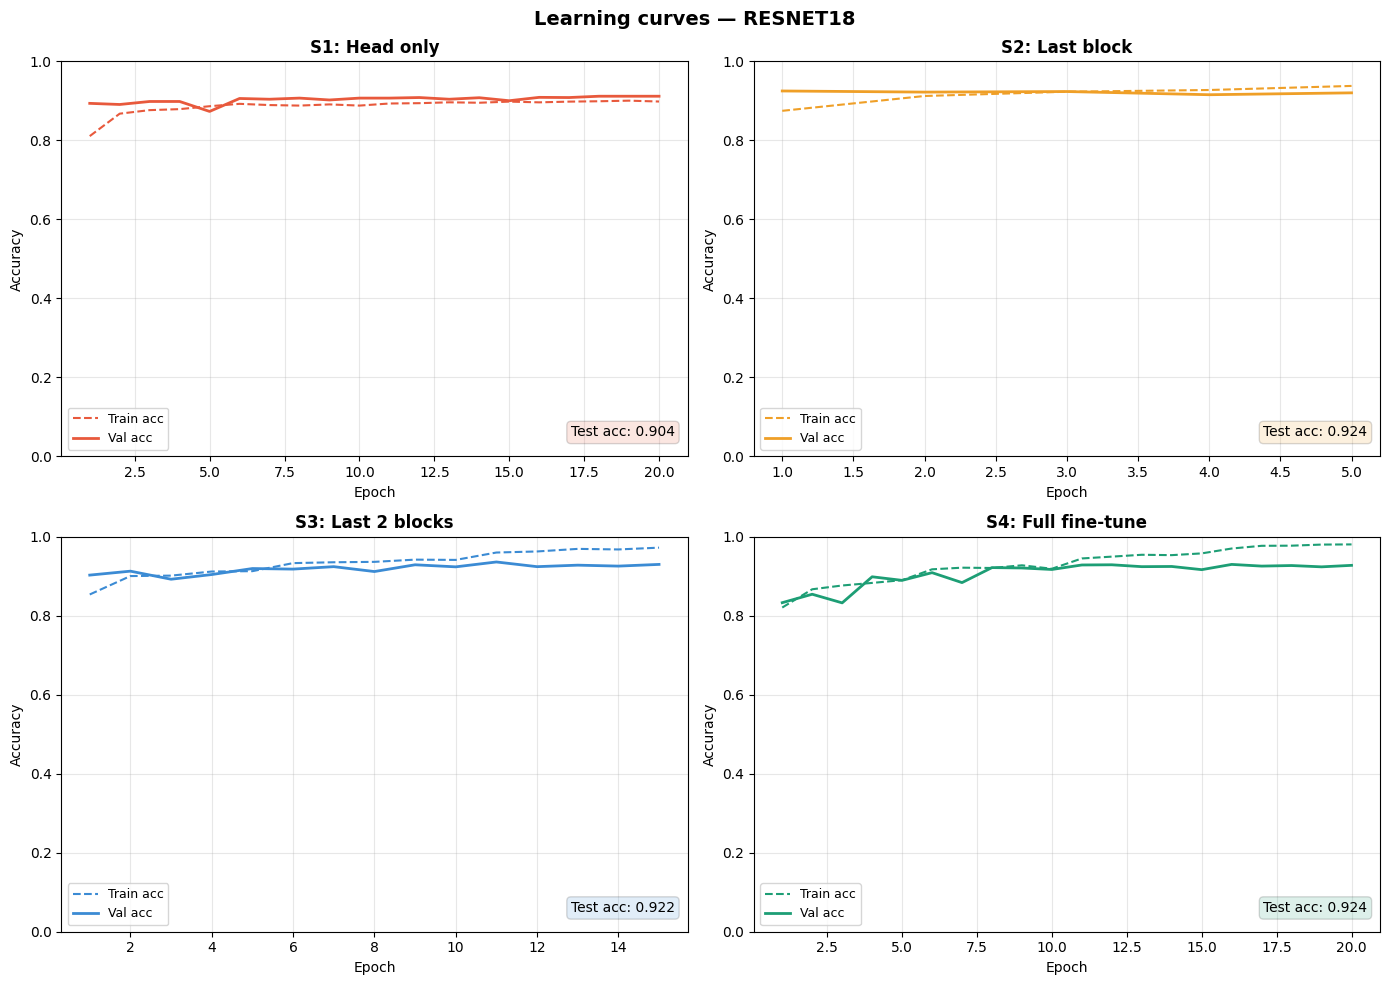


Summary Table:
| strategy   |   test_acc |   test_f1 |   avg_epoch_time_s |   total_train_time_s |   peak_mem_mib |   model_size_mb |   epochs_trained |
|:-----------|-----------:|----------:|-------------------:|---------------------:|---------------:|----------------:|-----------------:|
| S1         |      0.904 |     0.906 |             50.280 |             1005.670 |        378.800 |          42.720 |               20 |
| S2         |      0.924 |     0.925 |             50.160 |              250.810 |        474.500 |          42.720 |                5 |
| S3         |      0.922 |     0.924 |             51.380 |              770.830 |        501.200 |          42.720 |               15 |
| S4         |      0.924 |     0.926 |             57.250 |             1145.090 |        990.700 |          42.720 |               20 |


In [ ]:
# ============================================================
# CELL 8: Summary table + per-strategy learning curves
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = {'S1': '#E8593C', 'S2': '#EF9F27', 'S3': '#3B8BD4', 'S4': '#1D9E75'}
labels = {
    'S1': 'S1: Head only',
    'S2': 'S2: Last block',
    'S3': 'S3: Last 2 blocks',
    'S4': 'S4: Full fine-tune'
}

for i, result in enumerate(all_results):
    ax = axes[i // 2][i % 2]
    s  = result["strategy"]
    h  = result["history"]
    epochs = range(1, len(h["train_acc"]) + 1)
    ax.plot(epochs, h["train_acc"], color=colors[s], linestyle='--', linewidth=1.5, label='Train acc')
    ax.plot(epochs, h["val_acc"],   color=colors[s], linestyle='-',  linewidth=2,   label='Val acc')
    ax.set_title(labels[s], fontsize=12, fontweight='bold')
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.annotate(f"Test acc: {result['test_acc']:.3f}",
                xy=(0.98, 0.05), xycoords='axes fraction',
                ha='right', fontsize=10,
                bbox=dict(boxstyle='round', facecolor=colors[s], alpha=0.15))

plt.suptitle(f"Learning curves — {CONFIG['backbone'].upper()}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("learning_curves.png", dpi=150, bbox_inches='tight')
plt.show()

# Print formatted table
print("\nSummary Table:")
print(df.to_markdown(index=False, floatfmt=".3f"))

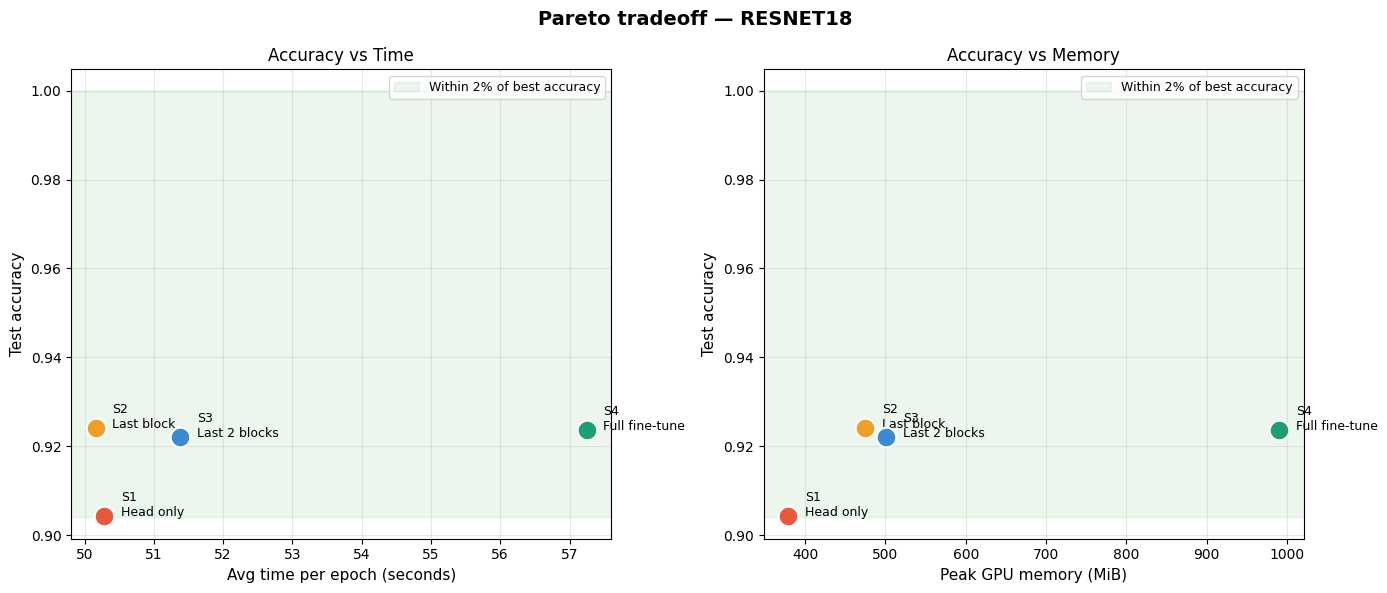

In [ ]:
# ============================================================
# CELL 9: Accuracy vs Time and Accuracy vs Memory (Pareto plots)
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

strategy_labels = {
    'S1': 'S1\nHead only',
    'S2': 'S2\nLast block',
    'S3': 'S3\nLast 2 blocks',
    'S4': 'S4\nFull fine-tune'
}

for result in all_results:
    s   = result["strategy"]
    col = colors[s]

    # Plot 1: Accuracy vs Avg epoch time
    ax1.scatter(result["avg_epoch_time_s"], result["test_acc"],
                color=col, s=200, zorder=5, edgecolors='white', linewidth=1.5)
    ax1.annotate(strategy_labels[s],
                 (result["avg_epoch_time_s"], result["test_acc"]),
                 textcoords="offset points", xytext=(12, 0), fontsize=9)

    # Plot 2: Accuracy vs Peak memory
    ax2.scatter(result["peak_mem_mib"], result["test_acc"],
                color=col, s=200, zorder=5, edgecolors='white', linewidth=1.5)
    ax2.annotate(strategy_labels[s],
                 (result["peak_mem_mib"], result["test_acc"]),
                 textcoords="offset points", xytext=(12, 0), fontsize=9)

# Draw a "Pareto frontier" annotation
for ax, xlabel in [(ax1, "Avg time per epoch (seconds)"),
                   (ax2, "Peak GPU memory (MiB)")]:
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel("Test accuracy", fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_title(f"Accuracy vs {'Time' if 'time' in xlabel.lower() else 'Memory'}", fontsize=12)

    # Shade the Pareto-efficient region
    ax.axhspan(
        max(r["test_acc"] for r in all_results) - 0.02,
        1.0, alpha=0.07, color='green',
        label='Within 2% of best accuracy'
    )
    ax.legend(fontsize=9)

plt.suptitle(f"Pareto tradeoff — {CONFIG['backbone'].upper()}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("pareto_plots.png", dpi=150, bbox_inches='tight')
plt.show()

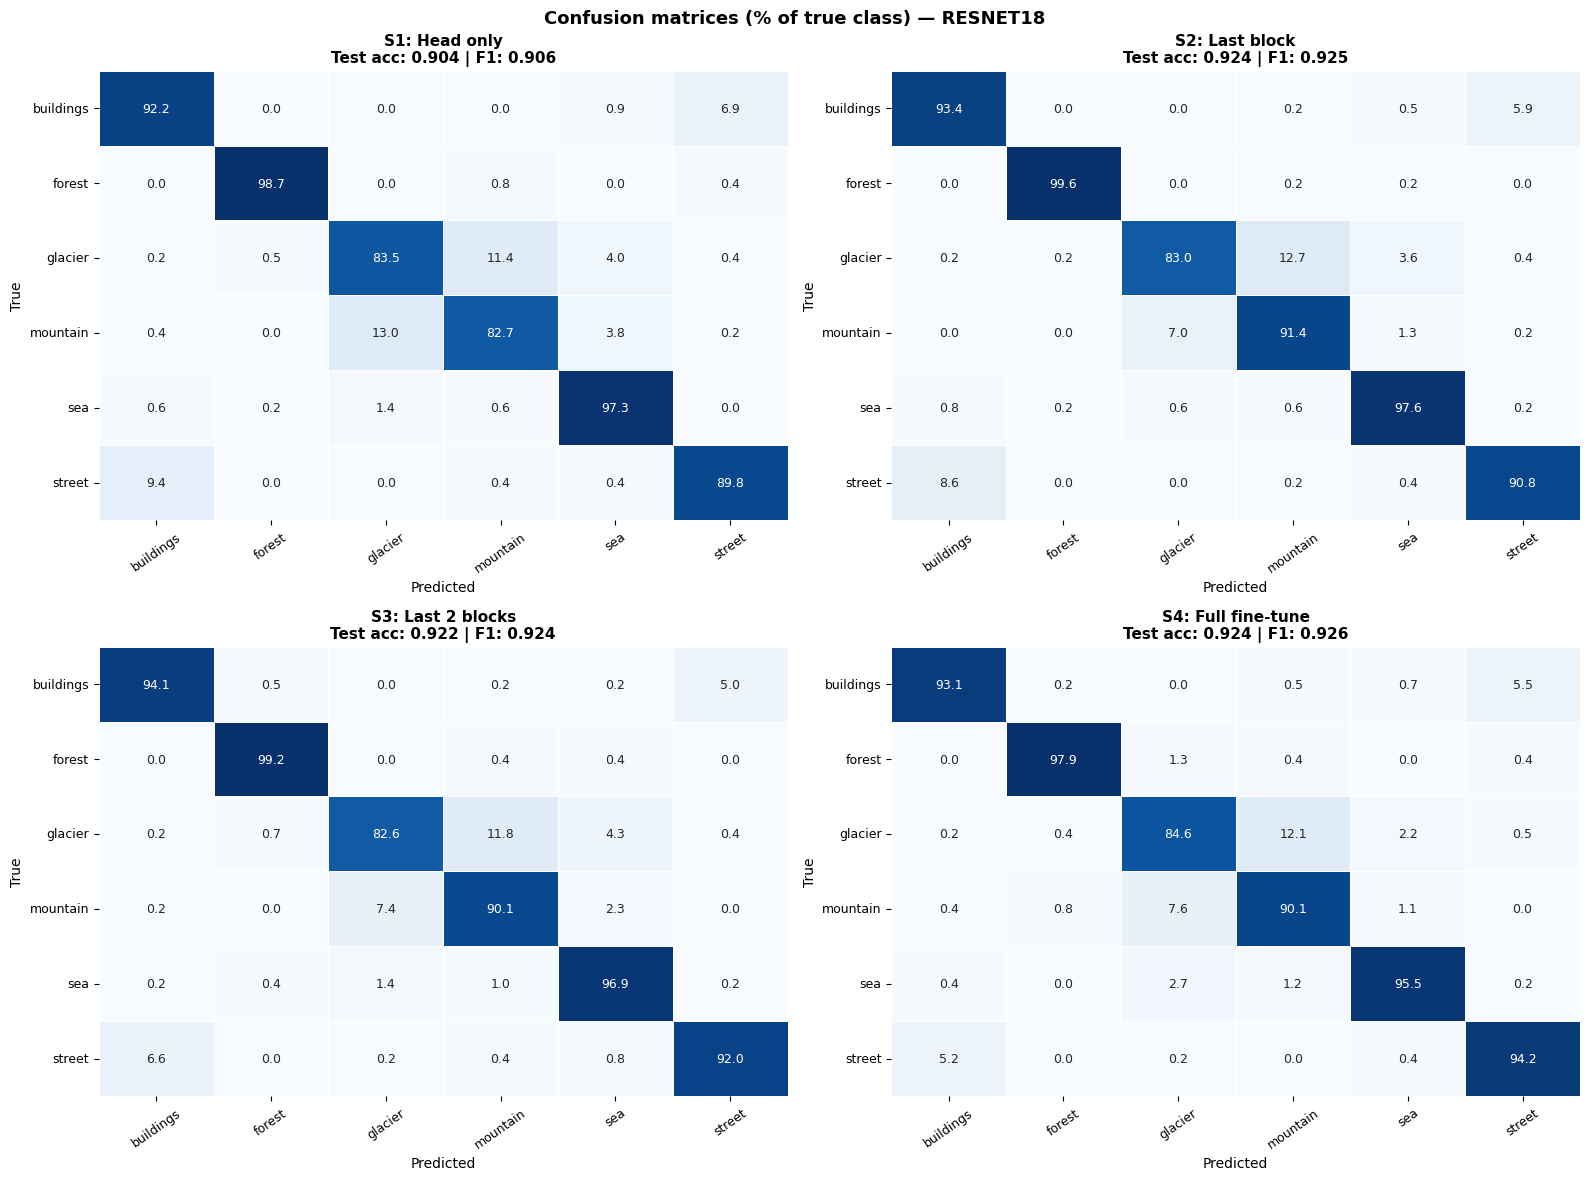

In [ ]:
# ============================================================
# CELL 10: Confusion matrices for all 4 strategies
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for i, result in enumerate(all_results):
    ax  = axes[i // 2][i % 2]
    s   = result["strategy"]
    cm  = confusion_matrix(result["test_labels"], result["test_preds"])

    # Normalize to percentages
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, cbar=False, linewidths=0.5,
                annot_kws={"size": 9})
    ax.set_title(f"{labels[s]}\nTest acc: {result['test_acc']:.3f} | F1: {result['test_f1']:.3f}",
                 fontsize=11, fontweight='bold')
    ax.set_xlabel("Predicted", fontsize=10)
    ax.set_ylabel("True", fontsize=10)
    ax.tick_params(axis='x', rotation=35, labelsize=9)
    ax.tick_params(axis='y', rotation=0, labelsize=9)

plt.suptitle(f"Confusion matrices (% of true class) — {CONFIG['backbone'].upper()}",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches='tight')
plt.show()

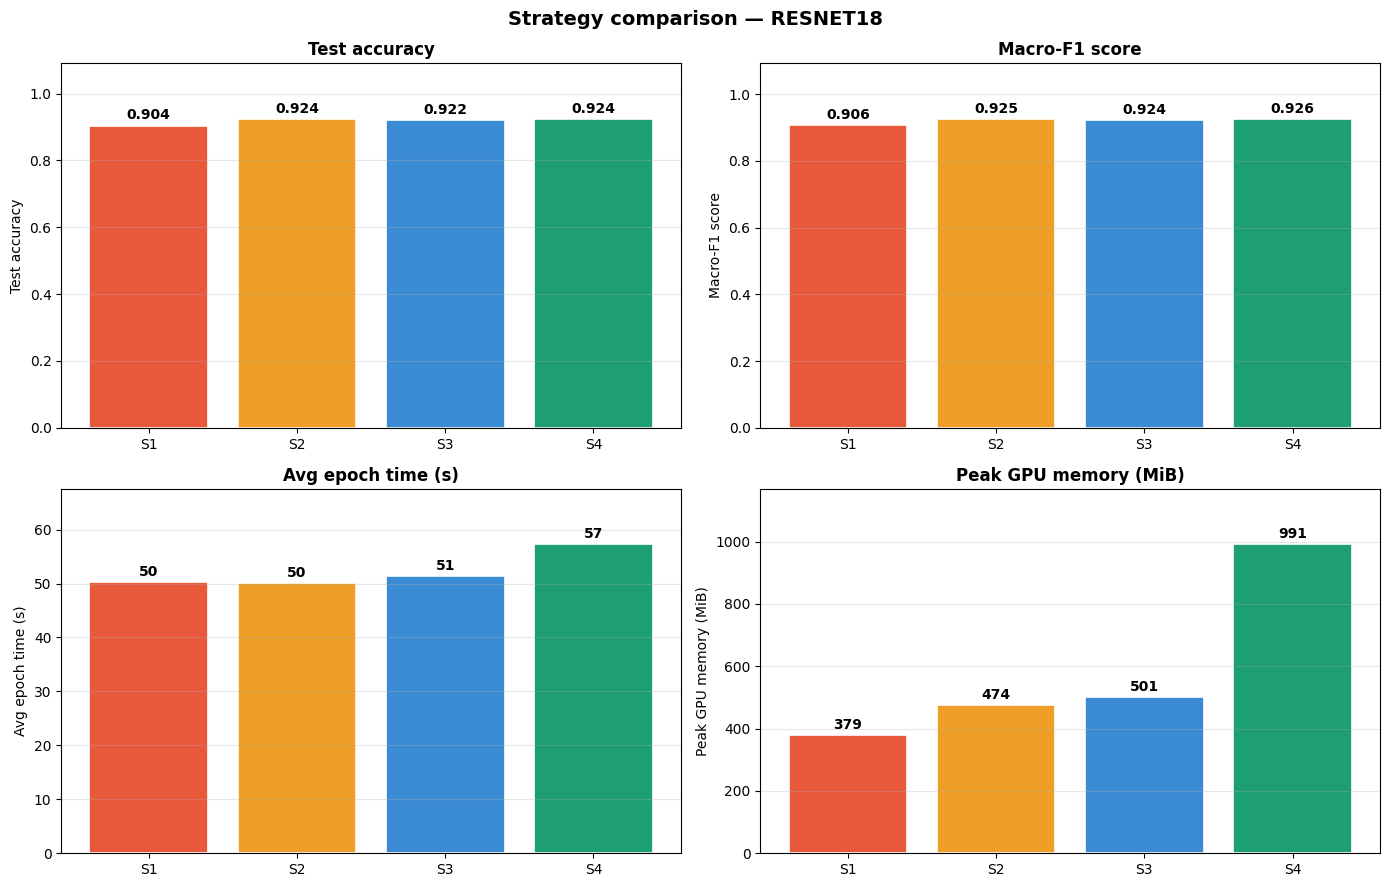

In [ ]:
# ============================================================
# CELL 11: Bar charts comparing all efficiency metrics
# ============================================================
metrics = {
    "Test accuracy":        "test_acc",
    "Macro-F1 score":       "test_f1",
    "Avg epoch time (s)":   "avg_epoch_time_s",
    "Peak GPU memory (MiB)":"peak_mem_mib",
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
strats    = [r["strategy"] for r in all_results]
bar_colors = [colors[s] for s in strats]

for ax, (title, key) in zip(axes.flatten(), metrics.items()):
    vals = [r[key] for r in all_results]
    bars = ax.bar(strats, vals, color=bar_colors, edgecolor='white', linewidth=1.2)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel(title)
    ax.set_ylim(0, max(vals) * 1.18)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.01,
                f"{val:.3f}" if val < 10 else f"{val:.0f}",
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle(f"Strategy comparison — {CONFIG['backbone'].upper()}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("metric_bars.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# CELL 12: Automated Pareto frontier + practitioner guideline
# ============================================================

def is_pareto_optimal(result, all_results):
    """
    A strategy is Pareto-dominated if another strategy has:
      - higher (or equal) accuracy AND lower (or equal) time AND lower (or equal) memory
    with at least one strictly better.
    """
    for other in all_results:
        if other["strategy"] == result["strategy"]:
            continue
        if (other["test_acc"]       >= result["test_acc"] and
            other["avg_epoch_time_s"] <= result["avg_epoch_time_s"] and
            other["peak_mem_mib"]     <= result["peak_mem_mib"] and
            (other["test_acc"]       > result["test_acc"] or
             other["avg_epoch_time_s"] < result["avg_epoch_time_s"] or
             other["peak_mem_mib"]     < result["peak_mem_mib"])):
            return False
    return True

print("=" * 60)
print("PARETO FRONTIER ANALYSIS")
print("=" * 60)

best_acc = max(r["test_acc"] for r in all_results)

for result in all_results:
    s        = result["strategy"]
    pareto   = is_pareto_optimal(result, all_results)
    acc_drop = best_acc - result["test_acc"]
    time_pct = result["avg_epoch_time_s"] / max(r["avg_epoch_time_s"] for r in all_results) * 100
    mem_pct  = result["peak_mem_mib"]     / max(r["peak_mem_mib"]     for r in all_results) * 100

    star = "★ PARETO OPTIMAL" if pareto else ""
    print(f"\n{s} ({labels[s].replace(chr(10),' ')}): {star}")
    print(f"  Accuracy: {result['test_acc']:.4f} (Δ from best: -{acc_drop:.4f})")
    print(f"  Epoch time: {result['avg_epoch_time_s']:.1f}s  ({time_pct:.0f}% of slowest)")
    print(f"  Memory:    {result['peak_mem_mib']:.0f} MiB ({mem_pct:.0f}% of heaviest)")

# Find best tradeoff: highest accuracy within 3% of best, with minimum time
candidates = [r for r in all_results if (best_acc - r["test_acc"]) <= 0.03]
recommended = min(candidates, key=lambda r: r["avg_epoch_time_s"])

print("\n" + "=" * 60)
print("PRACTITIONER RECOMMENDATION")
print("=" * 60)
print(f"""
Backbone       : {CONFIG['backbone'].upper()}
Dataset        : Intel Image Classification (6 classes)
Best overall   : {max(all_results, key=lambda r: r['test_acc'])['strategy']}
                 (acc={max(r['test_acc'] for r in all_results):.4f})

★ Recommended  : {recommended['strategy']}
  → Achieves {recommended['test_acc']:.4f} accuracy
    (within {(best_acc - recommended['test_acc'])*100:.1f}% of best)
  → {recommended['avg_epoch_time_s']:.1f}s/epoch  vs
     {max(r['avg_epoch_time_s'] for r in all_results):.1f}s/epoch (full fine-tune)
  → {recommended['peak_mem_mib']:.0f} MiB peak memory

GUIDELINE FOR SMALL/MEDIUM DATASETS (≤10k images, ≤10 classes):
  1. Start with S2 (unfreeze last block only).
  2. If accuracy is insufficient, try S3 (last 2 blocks).
  3. Only use S4 (full fine-tune) if you have > 5k samples/class
     and are hitting an accuracy ceiling.
  4. S1 (head only) is a useful baseline but rarely competitive.
""")

# Save recommendation
with open("recommendation.txt", "w") as f:
    f.write(f"Backbone: {CONFIG['backbone']}\n")
    f.write(f"Recommended strategy: {recommended['strategy']}\n")
    f.write(f"Test accuracy: {recommended['test_acc']}\n")
    f.write(f"Avg epoch time: {recommended['avg_epoch_time_s']}s\n")
    f.write(f"Peak memory: {recommended['peak_mem_mib']} MiB\n")

PARETO FRONTIER ANALYSIS

S1 (S1: Head only): ★ PARETO OPTIMAL
  Accuracy: 0.9043 (Δ from best: -0.0197)
  Epoch time: 50.3s  (88% of slowest)
  Memory:    379 MiB (38% of heaviest)

S2 (S2: Last block): ★ PARETO OPTIMAL
  Accuracy: 0.9240 (Δ from best: -0.0000)
  Epoch time: 50.2s  (88% of slowest)
  Memory:    474 MiB (48% of heaviest)

S3 (S3: Last 2 blocks): 
  Accuracy: 0.9220 (Δ from best: -0.0020)
  Epoch time: 51.4s  (90% of slowest)
  Memory:    501 MiB (51% of heaviest)

S4 (S4: Full fine-tune): 
  Accuracy: 0.9237 (Δ from best: -0.0003)
  Epoch time: 57.2s  (100% of slowest)
  Memory:    991 MiB (100% of heaviest)

PRACTITIONER RECOMMENDATION

Backbone       : RESNET18
Dataset        : Intel Image Classification (6 classes)
Best overall   : S2 
                 (acc=0.9240)

★ Recommended  : S2
  → Achieves 0.9240 accuracy 
    (within 0.0% of best)
  → 50.2s/epoch  vs 
     57.2s/epoch (full fine-tune)
  → 474 MiB peak memory

GUIDELINE FOR SMALL/MEDIUM DATASETS (≤10k image

In [ ]:
# ============================================================
# CELL 13: Download all result files to your local machine
# ============================================================
from google.colab import files

# Save complete results including per-epoch history
import json

full_results_export = []
for r in all_results:
    entry = {k: v for k, v in r.items() if k not in ("test_preds", "test_labels")}
    entry["history"] = r["history"]
    full_results_export.append(entry)

with open("full_results.json", "w") as f:
    json.dump(full_results_export, f, indent=2)

# Download everything
for fname in ["results_summary.csv", "full_results.json",
              "learning_curves.png", "pareto_plots.png",
              "confusion_matrices.png", "metric_bars.png",
              "recommendation.txt"]:
    if os.path.exists(fname):
        files.download(fname)
        print(f"Downloaded: {fname}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: results_summary.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: metric_bars.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: recommendation.txt
